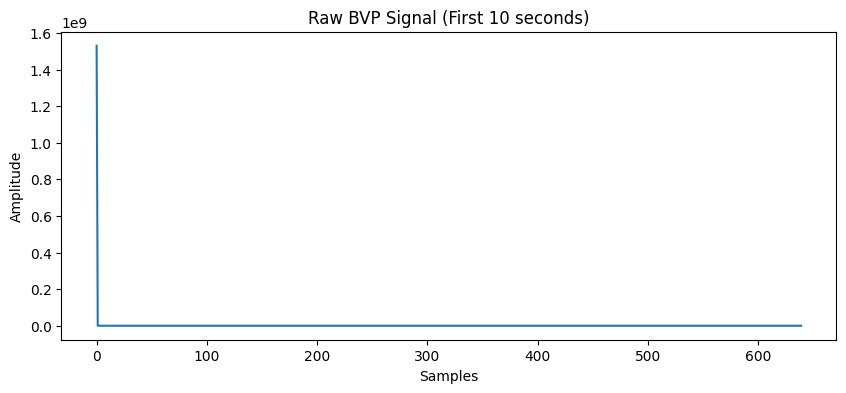

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# CHANGE THIS PATH to one of your BVP.csv files
bvp_path = "data/S1/BVP.csv"

# Load BVP signal
bvp = pd.read_csv(bvp_path, header=None)[0].values

# Plot first 10 seconds (Empatica E4 = 64 Hz)
fs = 64
plt.figure(figsize=(10, 4))
plt.plot(bvp[:fs*10])
plt.title("Raw BVP Signal (First 10 seconds)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


In [9]:
bvp_path = "data/S1/BVP.csv"   # change S1 if needed
bvp = pd.read_csv(bvp_path, header=None)[0].values

fs = 64  # Empatica E4 sampling rate


In [10]:
def bandpass_filter(signal, fs, low=0.5, high=8):
    nyq = 0.5 * fs
    b, a = butter(3, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal)


In [11]:
filtered_bvp = bandpass_filter(bvp, fs)


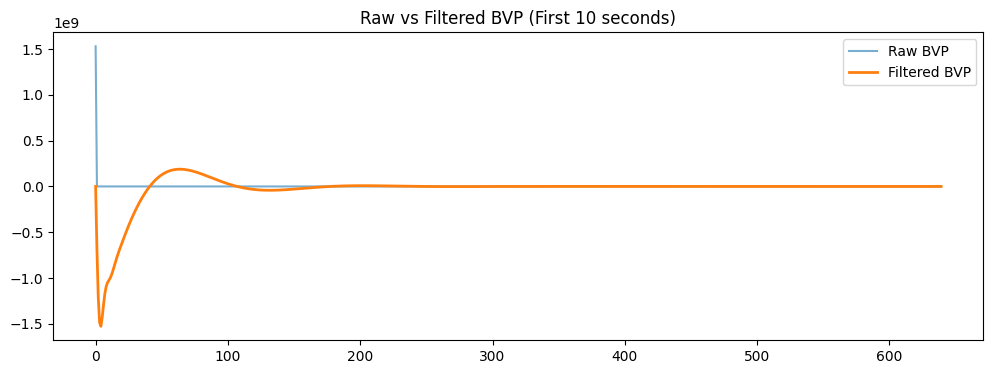

In [12]:
plt.figure(figsize=(12,4))
plt.plot(bvp[:fs*10], label="Raw BVP", alpha=0.6)
plt.plot(filtered_bvp[:fs*10], label="Filtered BVP", linewidth=2)
plt.legend()
plt.title("Raw vs Filtered BVP (First 10 seconds)")
plt.show()


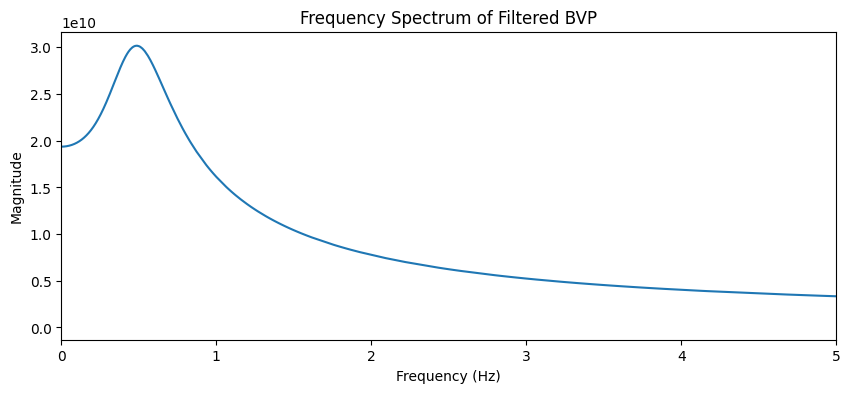

In [13]:
from scipy.fft import fft, fftfreq

N = len(filtered_bvp)
yf = fft(filtered_bvp)
xf = fftfreq(N, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.xlim(0, 5)
plt.title("Frequency Spectrum of Filtered BVP")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


In [14]:
import heartpy as hp


In [32]:
import numpy as np

# Normalize signal (VERY IMPORTANT)
segment = (segment - np.mean(segment)) / np.std(segment)


In [18]:
# Take 30 seconds of filtered signal
segment = filtered_bvp[:fs*30]


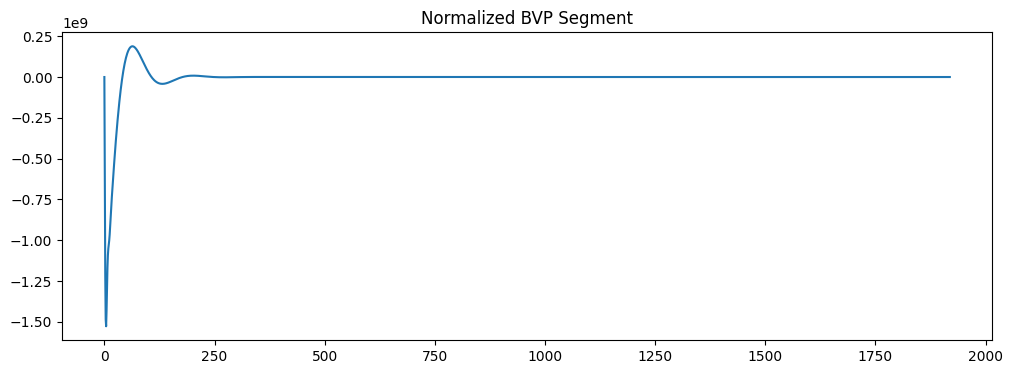

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(segment)
plt.title("Normalized BVP Segment")
plt.show()


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

bvp = pd.read_csv(bvp_path)

print(bvp.head())
print(bvp.shape)

   1530261892.00
0           64.0
1           -0.0
2           -0.0
3           -0.0
4           -0.0
(597906, 1)


In [26]:
wd, m = hp.process(
    segment,
    sample_rate=fs,
    bpmmin=40,
    bpmmax=180
)

print("Estimated Heart Rate (BPM):", round(m['bpm'], 2))


BadSignalWarning: 
----------------
Could not determine best fit for given signal. Please check the source signal.
 Probable causes:
- detected heart rate falls outside of bpmmin<->bpmmax constraints
- no detectable heart rate present in signal
- very noisy signal (consider filtering and scaling)
If you're sure the signal contains heartrate data, consider filtering and/or scaling first.
----------------


In [21]:
print("Segment length:", len(segment))
print("Sampling rate:", fs)


Segment length: 1920
Sampling rate: 64
